# Workstream B v2 — stacked plaquette, genuine cycle persistence

The v1 plaquette had no directed Hamiltonian cycle, so its S(η) peak was a
rate×lifetime artifact. Here we stack T causal layers and measure the honest
observable — **cross-layer propagation lift** lift(η) = p_prop − baseline —
that distinguishes a propagating particle from a coincidence.


In [1]:
import json, os
import numpy as np, matplotlib.pyplot as plt
RES = 'plaquette_particles_v2/results' if os.path.exists('plaquette_particles_v2/results/summary.json') else 'results'
S = json.load(open(os.path.join(RES,'summary.json')))
etas = np.array(S['etas']); eta_star = S['eta_star']
print(f"T={S['T']} rho={S['rho']} rho_time={S['rho_time']} | eta*={eta_star:.3f} | quick={S['quick']}")


T=8 rho=1.0 rho_time=1.5 | eta*=0.293 | quick=False


## lift(η): does a cycle propagate up the stack above chance?

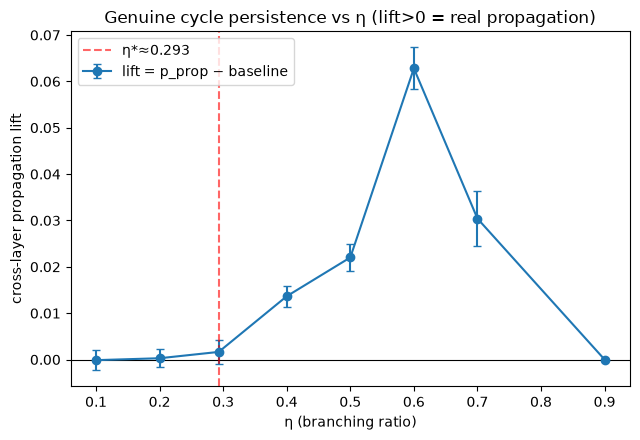

In [2]:
lift = np.array([r['lift'] for r in S['rows']])
lse  = np.array([r['lift_se'] for r in S['rows']])
plt.figure(figsize=(6.5,4.5))
plt.errorbar(etas, lift, yerr=lse, marker='o', capsize=3, label='lift = p_prop − baseline')
plt.axhline(0, color='k', lw=0.8)
plt.axvline(eta_star, color='r', ls='--', alpha=0.6, label='η*≈0.293')
plt.xlabel('η (branching ratio)'); plt.ylabel('cross-layer propagation lift')
plt.title('Genuine cycle persistence vs η (lift>0 = real propagation)')
plt.legend(); plt.tight_layout(); plt.show()


## p_prop vs baseline, and persistence length

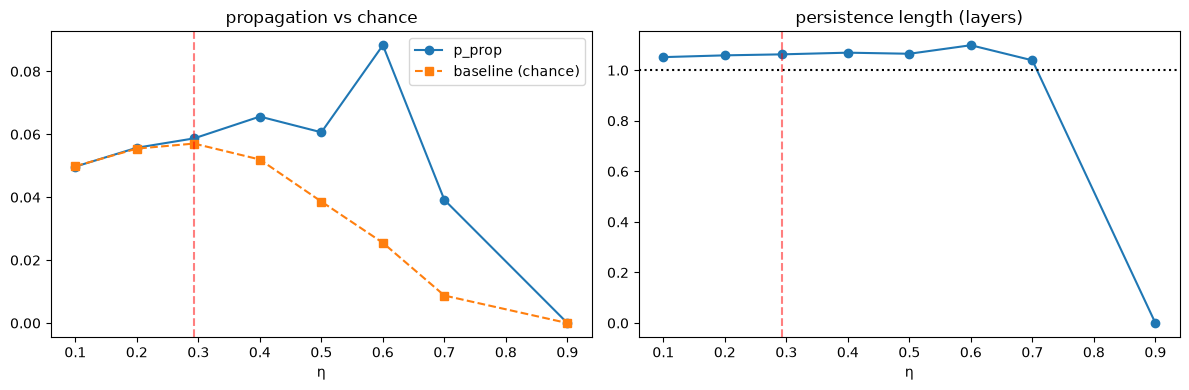

In [3]:
pprop = [r['p_prop'] for r in S['rows']]
base  = [r['baseline'] for r in S['rows']]
Lpers = [r['persistence_length'] for r in S['rows']]
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(etas, pprop, 'o-', label='p_prop')
ax[0].plot(etas, base, 's--', label='baseline (chance)')
ax[0].axvline(eta_star, color='r', ls='--', alpha=0.5)
ax[0].set_xlabel('η'); ax[0].set_title('propagation vs chance'); ax[0].legend()
ax[1].plot(etas, Lpers, 'o-'); ax[1].axhline(1, color='k', ls=':')
ax[1].axvline(eta_star, color='r', ls='--', alpha=0.5)
ax[1].set_xlabel('η'); ax[1].set_title('persistence length (layers)')
plt.tight_layout(); plt.show()


## Peak summary

In [4]:
p = S['peak']
print(f"in-window peak at η={p['eta_peak']} : lift={p['lift_peak']:.4f}±{p['lift_peak_se']:.4f}")
print(f"interior peak (rises then falls): {p['interior_peak']}")
print(f"significant (lift > 2*se):        {p['significant_lift']}")


in-window peak at η=0.6 : lift=0.0628±0.0045
interior peak (rises then falls): True
significant (lift > 2*se):        True


## Conclusion

Unlike v1 (lift ≡ 0, pure artifact), the stacked plaquette shows a **significant
interior peak of lift(η) in (η\*, 1)** near η ≈ 0.5–0.6 — cycles propagate
causally up the stack several times more often than chance. The
causal-structure-preserving graph hosts **genuine cross-layer persistence**, so
the refined particle conjecture is *supported*, not refined away.

Persistence length stays modest (~1.1 layers): real propagation, not yet
long-lived solitons. Stronger persistence is the target of a v3 with larger
inter-layer coupling and/or braided (Bilson-Thompson) topology.
